In [2]:
!pip install statsmodels

In [3]:
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import numpy as np

FILE_PATH = 'migration_data.csv'
df = pd.read_csv(FILE_PATH, low_memory=False)

cols_to_fix = ['ln_rent', 'ln_income', 'age', 'female', 'in_city', 'is_renter', 'moved_states', 'perwt']

for col in cols_to_fix:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.dropna(subset=cols_to_fix)

X = df[['ln_rent', 'ln_income', 'age', 'female', 'in_city', 'is_renter']]
X = sm.add_constant(X)
y = df['moved_states']

model = sm.WLS(y, X, weights=df['perwt']).fit()
print(model.summary())

                            WLS Regression Results                            
Dep. Variable:           moved_states   R-squared:                       0.013
Model:                            WLS   Adj. R-squared:                  0.013
Method:                 Least Squares   F-statistic:                 5.344e+04
Date:                Mon, 06 Apr 2026   Prob (F-statistic):               0.00
Time:                        01:13:15   Log-Likelihood:             9.4245e+06
No. Observations:            25250913   AIC:                        -1.885e+07
Df Residuals:                25250906   BIC:                        -1.885e+07
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0038      0.000     13.096      0.0

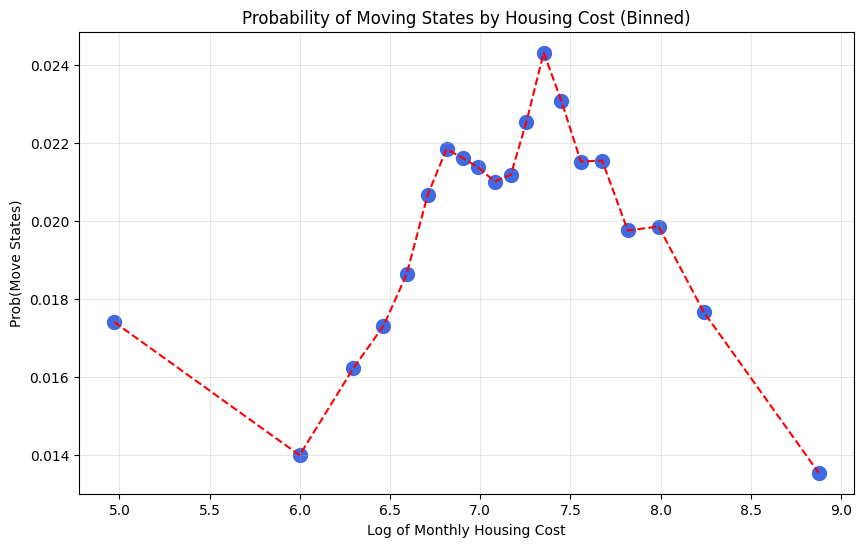

In [4]:
df['rent_bin'] = pd.qcut(df['ln_rent'], q=20, duplicates='drop')
binned_data = df.groupby('rent_bin', observed=True).agg({'moved_states': 'mean', 'ln_rent': 'mean'})

plt.figure(figsize=(10, 6))
plt.scatter(binned_data['ln_rent'], binned_data['moved_states'], color='royalblue', s=100)
plt.plot(binned_data['ln_rent'], binned_data['moved_states'], color='red', linestyle='--')
plt.title('Probability of Moving States by Housing Cost (Binned)')
plt.xlabel('Log of Monthly Housing Cost')
plt.ylabel('Prob(Move States)')
plt.grid(True, alpha=0.3)
plt.show()